# Baseline model — training

Trains `BaselineCNN` on the single-defect **train** split, checks the **val** split
after every epoch, saves the best checkpoint (by val macro-F1), then reports metrics.

The **test** split is not touched until the final section — run that once, at the end.

Modules used: `src/dataset.py`, `src/model.py`, `src/metrics.py`.

In [1]:
import os
from pathlib import Path

# This notebook lives in notebooks/. Move to the project root so the default
# "data/..." and "models/..." paths inside our modules resolve correctly.
if Path.cwd().name == "notebooks":
    os.chdir("..")
print("working dir:", Path.cwd())

import sys
sys.path.append("src")  # lets us `import dataset`, `import model`, `import metrics`

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from dataset import build_dataloaders
from model import BaselineCNN
from metrics import (evaluate_model, compute_metrics, print_metrics,
                     combo_mask, DEFECT_COLUMNS)

# Seed everything reproducible: weight initialisation + the per-epoch shuffle.
torch.manual_seed(42)
np.random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

working dir: c:\Users\Shamik\Desktop\ImageQuality_Classifier\ImageQuality_Classifier
device: cuda


## 1. Data

In [2]:
loaders = build_dataloaders(batch_size=32)
for name, ldr in loaders.items():
    print(f"{name:5s} {len(ldr.dataset):5d} images | {len(ldr):3d} batches")

train  3150 images |  99 batches
val     722 images |  23 batches
test    728 images |  23 batches


## 2. Model, loss, optimizer

- **model → device**: the weights have to live on the same device as the data (GPU).
- **`BCEWithLogitsLoss`**: the multi-label loss. Takes the raw logits, applies a
  sigmoid internally (per class), then binary cross-entropy. One loss covering all 5.
- **`Adam(lr=1e-3)`**: the optimizer. Each `step()` it adjusts every weight to
  reduce the loss; `1e-3` is the standard starting learning rate.

In [3]:
model = BaselineCNN().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(f"{sum(p.numel() for p in model.parameters()):,} parameters")

8,777,797 parameters


## 3. One training step (per batch of 32 images)

1. `optimizer.zero_grad()` — clear last batch's gradients (PyTorch adds them up otherwise)
2. `logits = model(images)` — forward pass
3. `loss = criterion(logits, labels)` — one number: how wrong this batch was
4. `loss.backward()` — fill in each weight's gradient (its share of the blame)
5. `optimizer.step()` — nudge every weight a little to reduce the loss

In [4]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """One full pass over the training data. Returns the average training loss."""
    model.train()  # training mode (matters once we add dropout/batchnorm later)
    running_loss, n_batches = 0.0, 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()             # 1. reset gradients
        logits = model(images)            # 2. forward
        loss = criterion(logits, labels)  # 3. how wrong?
        loss.backward()                   # 4. gradients
        optimizer.step()                  # 5. update weights

        running_loss += loss.item()
        n_batches += 1

    return running_loss / n_batches

## 4. The epoch loop

Each epoch: train once over the whole train split, then measure on val (no weight
updates). Save the checkpoint only when val macro-F1 beats the best seen so far.

In [5]:
NUM_EPOCHS = 10
CKPT_PATH = Path("models/baseline_best.pt")
CKPT_PATH.parent.mkdir(exist_ok=True)

history = []        # one row per epoch, for the plots
best_val_f1 = -1.0  # best validation macro-F1 seen so far

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(model, loaders["train"], criterion, optimizer, device)

    # validation pass
    y_true, y_prob, val_loss = evaluate_model(model, loaders["val"], device, criterion)
    vm = compute_metrics(y_true, y_prob)
    val_f1 = vm["macro_f1"]

    row = {"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss,
           "val_macro_f1": val_f1}
    for c in DEFECT_COLUMNS:
        row[f"f1_{c}"] = vm["per_class"][c]["f1"]
    history.append(row)

    flag = ""
    if val_f1 > best_val_f1:               # save best checkpoint
        best_val_f1 = val_f1
        torch.save(model.state_dict(), CKPT_PATH)
        flag = "  <- saved (best so far)"

    print(f"epoch {epoch:2d} | train_loss {train_loss:.4f} | val_loss {val_loss:.4f} "
          f"| val_macro_f1 {val_f1:.3f}{flag}")

print(f"\nbest val macro-F1: {best_val_f1:.3f}  ->  {CKPT_PATH}")

epoch  1 | train_loss 0.3125 | val_loss 0.3058 | val_macro_f1 0.508  <- saved (best so far)
epoch  2 | train_loss 0.2146 | val_loss 0.2635 | val_macro_f1 0.691  <- saved (best so far)
epoch  3 | train_loss 0.1759 | val_loss 0.3230 | val_macro_f1 0.687
epoch  4 | train_loss 0.1575 | val_loss 0.2534 | val_macro_f1 0.765  <- saved (best so far)
epoch  5 | train_loss 0.1437 | val_loss 0.2481 | val_macro_f1 0.779  <- saved (best so far)
epoch  6 | train_loss 0.1184 | val_loss 0.2717 | val_macro_f1 0.747
epoch  7 | train_loss 0.1148 | val_loss 0.2529 | val_macro_f1 0.777
epoch  8 | train_loss 0.1051 | val_loss 0.2243 | val_macro_f1 0.825  <- saved (best so far)
epoch  9 | train_loss 0.0833 | val_loss 0.2595 | val_macro_f1 0.829  <- saved (best so far)
epoch 10 | train_loss 0.0711 | val_loss 0.2258 | val_macro_f1 0.853  <- saved (best so far)

best val macro-F1: 0.853  ->  models\baseline_best.pt


In [6]:
hist = pd.DataFrame(history)
hist.to_csv("models/baseline_history.csv", index=False)
hist

,epoch,train_loss,val_loss,val_macro_f1,f1_blur,f1_underexposed,f1_overexposed,f1_noise,f1_contrast
0,1,0.312479,0.305840,0.507786,0.041958,0.902098,0.833333,0.000000,0.761538
1,2,0.214589,0.263519,0.691037,0.580645,0.911032,0.885246,0.282723,0.795539
2,3,0.175900,0.323009,0.686973,0.251572,0.930909,0.895753,0.568750,0.787879
3,4,0.157543,0.253445,0.764805,0.755906,0.939394,0.810811,0.484581,0.833333
4,5,0.143651,0.248094,0.779216,0.711111,0.939394,0.814480,0.592145,0.838951
5,6,0.118407,0.271746,0.746510,0.706422,0.930769,0.863309,0.416667,0.815385
6,7,0.114812,0.252893,0.777271,0.795082,0.924901,0.848485,0.464646,0.853242
7,8,0.105080,0.224274,0.825035,0.820312,0.946565,0.881890,0.597285,0.879121
8,9,0.083257,0.259452,0.829250,0.835821,0.937729,0.861925,0.619469,0.891304
9,10,0.071077,0.225823,0.852776,0.828125,0.937008,0.905512,0.699620,0.893617


## 5. Diagnostics

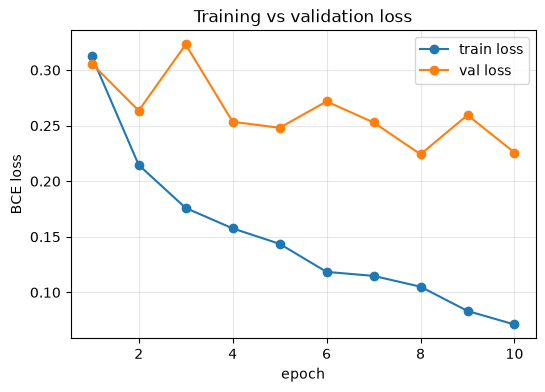

In [7]:
# Train vs validation loss. If val flattens/rises while train keeps falling -> overfitting.
plt.figure(figsize=(6, 4))
plt.plot(hist["epoch"], hist["train_loss"], marker="o", label="train loss")
plt.plot(hist["epoch"], hist["val_loss"], marker="o", label="val loss")
plt.xlabel("epoch"); plt.ylabel("BCE loss"); plt.title("Training vs validation loss")
plt.legend(); plt.grid(alpha=0.3); plt.show()

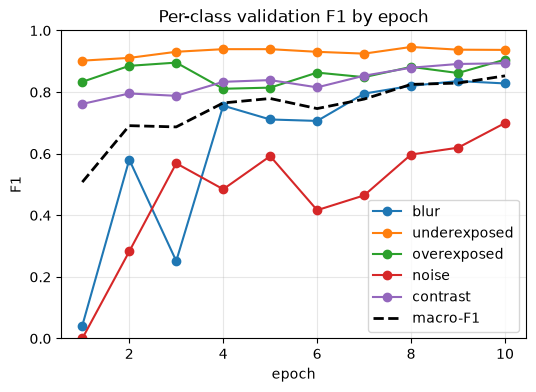

In [8]:
# Per-class validation F1 over epochs, with macro-F1 dashed on top.
plt.figure(figsize=(6, 4))
for c in DEFECT_COLUMNS:
    plt.plot(hist["epoch"], hist[f"f1_{c}"], marker="o", label=c)
plt.plot(hist["epoch"], hist["val_macro_f1"], "k--", linewidth=2, label="macro-F1")
plt.xlabel("epoch"); plt.ylabel("F1"); plt.title("Per-class validation F1 by epoch")
plt.legend(); plt.grid(alpha=0.3); plt.ylim(0, 1); plt.show()

## 6. Evaluate the best checkpoint on validation

Reload the saved weights (may not be the last epoch), then score the full val set
and the combo (multi-defect) subset separately.

In [9]:
best_model = BaselineCNN().to(device)
best_model.load_state_dict(torch.load(CKPT_PATH))

y_true, y_prob, _ = evaluate_model(best_model, loaders["val"], device)

print_metrics(compute_metrics(y_true, y_prob), "VAL - all images")

val_files = loaders["val"].dataset.df["filename"].values
mask = combo_mask(val_files)
print_metrics(compute_metrics(y_true[mask], y_prob[mask]),
              f"VAL - combo images only (n={int(mask.sum())})")

C:\Users\Shamik\AppData\Local\Temp\ipykernel_31884\1501455565.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model.load_state_dict(torch.load(CKPT_PATH))



=== VAL - all images ===
macro-F1 0.853 | macro-P 0.888 | macro-R 0.822 | subset-acc 0.788
class            prec  recall     f1  pr_auc    tp    fp    fn    tn
blur            0.906   0.763  0.828   0.911   106    11    33   572
underexposed    0.975   0.902  0.937   0.993   119     3    13   587
overexposed     0.927   0.885  0.906   0.956   115     9    15   583
noise           0.742   0.662  0.700   0.787    92    32    47   551
contrast        0.887   0.900  0.894   0.905   126    16    14   566

=== VAL - combo images only (n=50) ===
macro-F1 0.530 | macro-P 1.000 | macro-R 0.408 | subset-acc 0.000
class            prec  recall     f1  pr_auc    tp    fp    fn    tn
blur            1.000   0.185  0.312   0.851     5     0    22    23
underexposed    1.000   0.600  0.750   1.000    12     0     8    30
overexposed     1.000   0.611  0.759   0.994    11     0     7    32
noise           1.000   0.037  0.071   0.892     1     0    26    23
contrast        1.000   0.607  0.756   0.91

## 7. FINAL: test set — run once

Only run this after you have stopped changing the model. Everything before this
point should drive your decisions; this cell is the untouched final number.

In [ ]:
y_true, y_prob, _ = evaluate_model(best_model, loaders["test"], device)

print_metrics(compute_metrics(y_true, y_prob), "TEST - all images")

test_files = loaders["test"].dataset.df["filename"].values
mask = combo_mask(test_files)
print_metrics(compute_metrics(y_true[mask], y_prob[mask]),
              f"TEST - combo images only (n={int(mask.sum())})")